For the data: [https://hastie.su.domains/ElemStatLearn/datasets/SAheart.data](https://hastie.su.domains/ElemStatLearn/datasets/SAheart.data) (heart diseases in South Africa), calculate the resubstitution error and the 10-fold cross-validation (10CV) error for the 3-NN and RF (Random Forest) methods. For the Random Forest model, display the confusion matrix and interpret it. Which model would you recommend for this problem?

In [14]:
import pandas as pd
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load the dataset
url = "https://hastie.su.domains/ElemStatLearn/datasets/SAheart.data"
data = pd.read_csv(url)
data = data.drop('row.names', axis=1)
display(data)

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
0,160,12.00,5.73,23.11,Present,49,25.30,97.20,52,1
1,144,0.01,4.41,28.61,Absent,55,28.87,2.06,63,1
2,118,0.08,3.48,32.28,Present,52,29.14,3.81,46,0
3,170,7.50,6.41,38.03,Present,51,31.99,24.26,58,1
4,134,13.60,3.50,27.78,Present,60,25.99,57.34,49,1
...,...,...,...,...,...,...,...,...,...,...
457,214,0.40,5.98,31.72,Absent,64,28.45,0.00,58,0
458,182,4.20,4.41,32.10,Absent,52,28.61,18.72,52,1
459,108,3.00,1.59,15.23,Absent,40,20.09,26.64,55,0
460,118,5.40,11.61,30.79,Absent,64,27.35,23.97,40,0


In [15]:
data['famhist'] = LabelEncoder().fit_transform(data['famhist'])
X = data.drop('chd', axis=1)
y = data['chd']

# Scale features (critical for distance-based methods like KNN)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

display(X_scaled.head())
display(y)

# 3-NN with scaled features
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_scaled, y)
y_pred_knn = knn.predict(X_scaled)
resub_error_knn = 1 - accuracy_score(y, y_pred_knn)
print(f"3-NN Resubstitution error rate: {round(resub_error_knn * 100, 2)}%")

cv_scores_knn = cross_val_score(knn, X_scaled, y, cv=10)
cv_error_knn = 1 - cv_scores_knn.mean()
print(f"3-NN 10-CV error rate: {round(cv_error_knn * 100, 2)}%")

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age
0,1.058564,1.823073,0.478412,-0.295503,1.185854,-0.418470,-0.176786,3.277738,0.629336
1,0.277089,-0.790237,-0.159680,0.412140,-0.843274,0.193344,0.671373,-0.612745,1.383115
2,-0.992806,-0.774980,-0.609245,0.884332,1.185854,-0.112563,0.735519,-0.541183,0.218184
3,1.546985,0.842264,0.807126,1.624141,1.185854,-0.214532,1.412621,0.295062,1.040488
4,-0.211332,2.171805,-0.599577,0.305351,1.185854,0.703189,-0.012856,1.647775,0.423760


0      1
1      1
2      0
3      1
4      1
      ..
457    0
458    1
459    0
460    0
461    1
Name: chd, Length: 462, dtype: int64

3-NN Resubstitution error rate: 20.56%
3-NN 10-CV error rate: 31.83%


RF Resubstitution error rate: 0.0%
RF 10-CV error rate: 30.95%


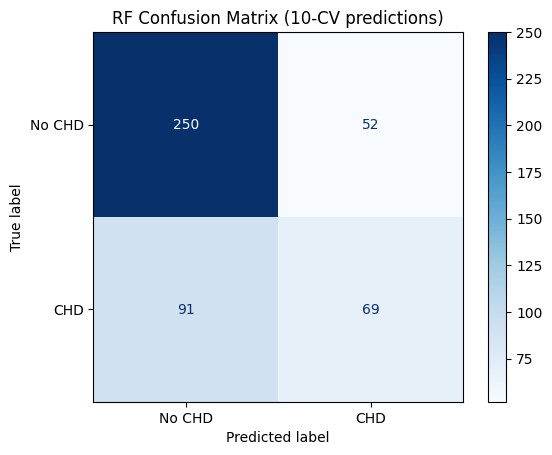


Confusion Matrix Interpretation:
  TN = 250: correctly identified as No CHD
  FP = 52: healthy patients misclassified as CHD
  FN = 91: CHD patients missed (dangerous)
  TP = 69: correctly identified CHD

  Recall (CHD)    = 69/160 = 43.1%
  Precision (CHD) = 69/121 = 57.0%


In [16]:
# Random Forest (scaling not needed for tree-based methods, using original X)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

y_pred_rf = rf.predict(X)
resub_error_rf = 1 - accuracy_score(y, y_pred_rf)
print(f"RF Resubstitution error rate: {round(resub_error_rf * 100, 2)}%")

cv_scores_rf = cross_val_score(rf, X, y, cv=10)
cv_error_rf = 1 - cv_scores_rf.mean()
print(f"RF 10-CV error rate: {round(cv_error_rf * 100, 2)}%")

# Confusion matrix using cross-validated predictions (more honest than resubstitution)
y_pred_rf_cv = cross_val_predict(rf, X, y, cv=10)
cm = confusion_matrix(y, y_pred_rf_cv)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No CHD', 'CHD'])
disp.plot(cmap=plt.cm.Blues)
plt.title('RF Confusion Matrix (10-CV predictions)')
plt.show()

# Print detailed metrics
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Interpretation:")
print(f"  TN = {tn}: correctly identified as No CHD")
print(f"  FP = {fp}: healthy patients misclassified as CHD")
print(f"  FN = {fn}: CHD patients missed (dangerous)")
print(f"  TP = {tp}: correctly identified CHD")
print(f"\n  Recall (CHD)    = {tp}/{tp+fn} = {tp/(tp+fn)*100:.1f}%")
print(f"  Precision (CHD) = {tp}/{tp+fp} = {tp/(tp+fp)*100:.1f}%")

RF (balanced) Resubstitution error rate: 0.0%
RF (balanced) 10-CV error rate: 32.03%


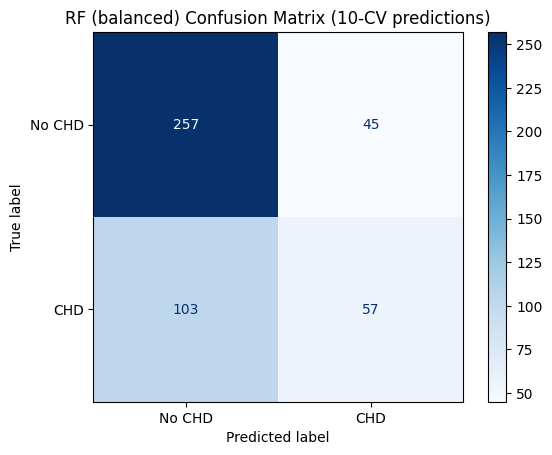


Confusion Matrix Interpretation (balanced):
  TN = 257: correctly identified as No CHD
  FP = 45: healthy patients misclassified as CHD
  FN = 103: CHD patients missed
  TP = 57: correctly identified CHD

  Recall (CHD)    = 57/160 = 35.6%
  Precision (CHD) = 57/102 = 55.9%

Comparison: RF vs RF (balanced)
  Metric                       RF  RF balanced
  CV Error                 30.95%       32.03%
  Recall (CHD)              43.1%        35.6%
  Precision (CHD)           57.0%        55.9%


In [17]:
# Random Forest with class_weight='balanced' to address class imbalance
rf_balanced = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_balanced.fit(X, y)

y_pred_rfb = rf_balanced.predict(X)
resub_error_rfb = 1 - accuracy_score(y, y_pred_rfb)
print(f"RF (balanced) Resubstitution error rate: {round(resub_error_rfb * 100, 2)}%")

cv_scores_rfb = cross_val_score(rf_balanced, X, y, cv=10)
cv_error_rfb = 1 - cv_scores_rfb.mean()
print(f"RF (balanced) 10-CV error rate: {round(cv_error_rfb * 100, 2)}%")

# Confusion matrix
y_pred_rfb_cv = cross_val_predict(rf_balanced, X, y, cv=10)
cm_balanced = confusion_matrix(y, y_pred_rfb_cv)
disp_balanced = ConfusionMatrixDisplay(confusion_matrix=cm_balanced, display_labels=['No CHD', 'CHD'])
disp_balanced.plot(cmap=plt.cm.Blues)
plt.title('RF (balanced) Confusion Matrix (10-CV predictions)')
plt.show()

tn_b, fp_b, fn_b, tp_b = cm_balanced.ravel()
print(f"\nConfusion Matrix Interpretation (balanced):")
print(f"  TN = {tn_b}: correctly identified as No CHD")
print(f"  FP = {fp_b}: healthy patients misclassified as CHD")
print(f"  FN = {fn_b}: CHD patients missed")
print(f"  TP = {tp_b}: correctly identified CHD")
print(f"\n  Recall (CHD)    = {tp_b}/{tp_b+fn_b} = {tp_b/(tp_b+fn_b)*100:.1f}%")
print(f"  Precision (CHD) = {tp_b}/{tp_b+fp_b} = {tp_b/(tp_b+fp_b)*100:.1f}%")

# Compare with unbalanced RF
print(f"\n{'='*50}")
print(f"Comparison: RF vs RF (balanced)")
print(f"{'='*50}")
print(f"  {'Metric':<20} {'RF':>10} {'RF balanced':>12}")
print(f"  {'CV Error':<20} {cv_error_rf*100:>9.2f}% {cv_error_rfb*100:>11.2f}%")
print(f"  {'Recall (CHD)':<20} {tp/(tp+fn)*100:>9.1f}% {tp_b/(tp_b+fn_b)*100:>11.1f}%")
print(f"  {'Precision (CHD)':<20} {tp/(tp+fp)*100:>9.1f}% {tp_b/(tp_b+fp_b)*100:>11.1f}%")

## Summary and Recommendation

| Model | Resub Error | 10-CV Error | Recall (CHD) | Precision (CHD) |
|-------|-------------|-------------|--------------|-----------------|
| 3-NN (scaled) | 20.56% | 31.83% | — | — |
| Random Forest | 0.0% | **30.95%** | **43.1%** | **57.0%** |
| RF (balanced) | 0.0% | 32.03% | 35.6% | 55.9% |

**Confusion Matrix Interpretation (RF):** The unbalanced RF correctly identifies most No-CHD patients (TN=250), but misses 91 out of 160 actual CHD cases (FN=91). Recall for CHD is only 43.1%, meaning over half of heart disease patients go undetected.

**`class_weight='balanced'` did not help:** Despite addressing the ~2:1 class imbalance, the balanced RF performed worse across all metrics — higher CV error (32.03% vs 30.95%), lower recall (35.6% vs 43.1%), and lower precision (55.9% vs 57.0%). The imbalance in this dataset is not severe enough for class weighting to be beneficial, and it appears to add noise to the decision boundaries.

**Recommendation:** The **unbalanced Random Forest** is the best model (lowest CV error at 30.95%). Key takeaways:
- Feature scaling improved KNN significantly (CV error from ~41.6% to 31.83%), confirming scaling is critical for distance-based methods.
- RF's 0% resubstitution error vs 30.95% CV error indicates overfitting.
- The limited predictive power of the features — rather than class imbalance — is the main bottleneck for CHD detection in this dataset.